In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from fractions import Fraction

In [2]:
import pandas as pd
df = pd.read_csv('../output/Bach_chordify_roman_5.csv')
display(df.head())
df.drop(['file', 'position'], axis=1, inplace=True)

,lookback_1,lookback_2,lookback_3,lookback_4,lookback_5,label,duration,file,position
0,START,START,START,START,START,iii,0.25,"Bach, Carl Philipp Emanuel, Keyboard Sonata in...",0
1,START,START,START,START,iii,vi,0.25,"Bach, Carl Philipp Emanuel, Keyboard Sonata in...",1
2,START,START,START,iii,vi,vi,0.25,"Bach, Carl Philipp Emanuel, Keyboard Sonata in...",2
3,START,START,iii,vi,vi,v,0.50,"Bach, Carl Philipp Emanuel, Keyboard Sonata in...",3
4,START,iii,vi,vi,v,#i,0.50,"Bach, Carl Philipp Emanuel, Keyboard Sonata in...",4


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import LabelEncoder

#Apply labels
lookback_cols = [c for c in df.columns if 'lookback' in c and df[c].dtype == 'object' or 'label' in c]

all_chords = set(df['label'].unique())
for col in lookback_cols:
    all_chords |= set(df[col].dropna().unique())

le_chord = LabelEncoder()
le_chord.fit(sorted(all_chords))

for col in lookback_cols:
    df[col] = le_chord.transform(df[col])


display(df.head())

,lookback_1,lookback_2,lookback_3,lookback_4,lookback_5,label,duration
0,9,9,9,9,9,20,0.25
1,9,9,9,9,20,23,0.25
2,9,9,9,20,23,23,0.25
3,9,9,20,23,23,22,0.50
4,9,20,23,23,22,0,0.50


In [4]:
#Apply labels
X_chord = df.drop(columns=['label', 'duration'])
y_chord = df['label']
X_duration = df.drop(columns=['duration'])
df['duration'] = df['duration'].apply(lambda x: Fraction(x).limit_denominator())
le_dur = LabelEncoder()
le_dur.fit(sorted(df['duration'].unique()))
df['duration'] = le_dur.transform(df['duration'])
y_duration = df['duration']
print("Training samples:", X_chord.shape[0])
print("Feature dims:",    X_chord.shape[1])
display(X_chord.head())
display(y_duration.head())

Training samples: 200525
Feature dims: 5


,lookback_1,lookback_2,lookback_3,lookback_4,lookback_5
0,9,9,9,9,9
1,9,9,9,9,20
2,9,9,9,20,23
3,9,9,20,23,23
4,9,20,23,23,22


0    2
1    2
2    2
3    5
4    5
Name: duration, dtype: int64

In [5]:
n_samples = X_chord.shape[0]
n_features = X_chord.shape[1]
print(f"Ratio samples/features = {n_samples/n_features:.1f}")

Ratio samples/features = 40105.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_chord, y_chord, test_size=0.2, random_state=42)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_duration, y_duration, test_size=0.2, random_state=42)
display(yd_train.head())

151994    0
104651    2
148815    8
31761     4
146666    2
Name: duration, dtype: int64

In [14]:
from sklearn.metrics import accuracy_score
clf_chord = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=10, min_samples_leaf=10, min_samples_split=50)
clf_duration = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=10, min_samples_leaf=10, min_samples_split=50)
clf_chord.fit(Xc_train, yc_train)
clf_duration.fit(Xd_train, yd_train)
yc_pred = clf_chord.predict(Xc_test)
yd_pred = clf_duration.predict(Xd_test)
print("Test accuracy (chord):", accuracy_score(yc_test, yc_pred))
print("Test accuracy (duration):", accuracy_score(yd_test, yd_pred))

Test accuracy (chord): 0.39089889041266673
Test accuracy (duration): 0.3834933300087271


In [15]:
import numpy as np
import pandas as pd

chord_cols = clf_chord.feature_names_in_
dur_cols   = clf_duration.feature_names_in_

#Choose initial music starter
init_chord_ctx = list(Xc_test.iloc[0])
init_dur_ctx   = list(Xd_test.iloc[0])[: len(Xd_test.iloc[0]) - len(init_chord_ctx)]

steps      = 128
generated  = []
chord_ctx  = init_chord_ctx.copy()
dur_ctx    = init_dur_ctx.copy()

for step in range(steps):
    #Iterate through loop, predict likely chord using chord context.
    Xc_df = pd.DataFrame([chord_ctx], columns=chord_cols)
    proba_c = clf_chord.predict_proba(Xc_df)[0]
    enc_chord = np.random.choice(clf_chord.classes_, p=proba_c)

    #Add chord to duration context and predict duration.
    chord_ctx = chord_ctx[1:] + [enc_chord]
    Xd_df = pd.DataFrame([chord_ctx + dur_ctx], columns=dur_cols)
    proba_d = clf_duration.predict_proba(Xd_df)[0]
    next_dur = np.random.choice(clf_duration.classes_, p=proba_d)
    dur_ctx = dur_ctx[1:] + [next_dur]
    
    generated.append({
        'chord':    enc_chord,
        'duration': next_dur
    })

#Decode data and return to frame.
df_gen = pd.DataFrame(generated)
df_gen['chord'] = le_chord.inverse_transform(df_gen['chord'].values)
df_gen['duration'] = le_dur.inverse_transform(df_gen['duration'].values)
df_gen.to_csv('generated_sequence_tree.csv', index=False)
print(f"\nWrote {len(df_gen)} events to generated_sequence_full.csv")


Wrote 128 events to generated_sequence_full.csv


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import HalvingGridSearchCV
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [None, 5, 10, 20, 50],
    'min_samples_split':[2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 10],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(Xc_train, yc_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best CV accuracy: 0.39220795412043385


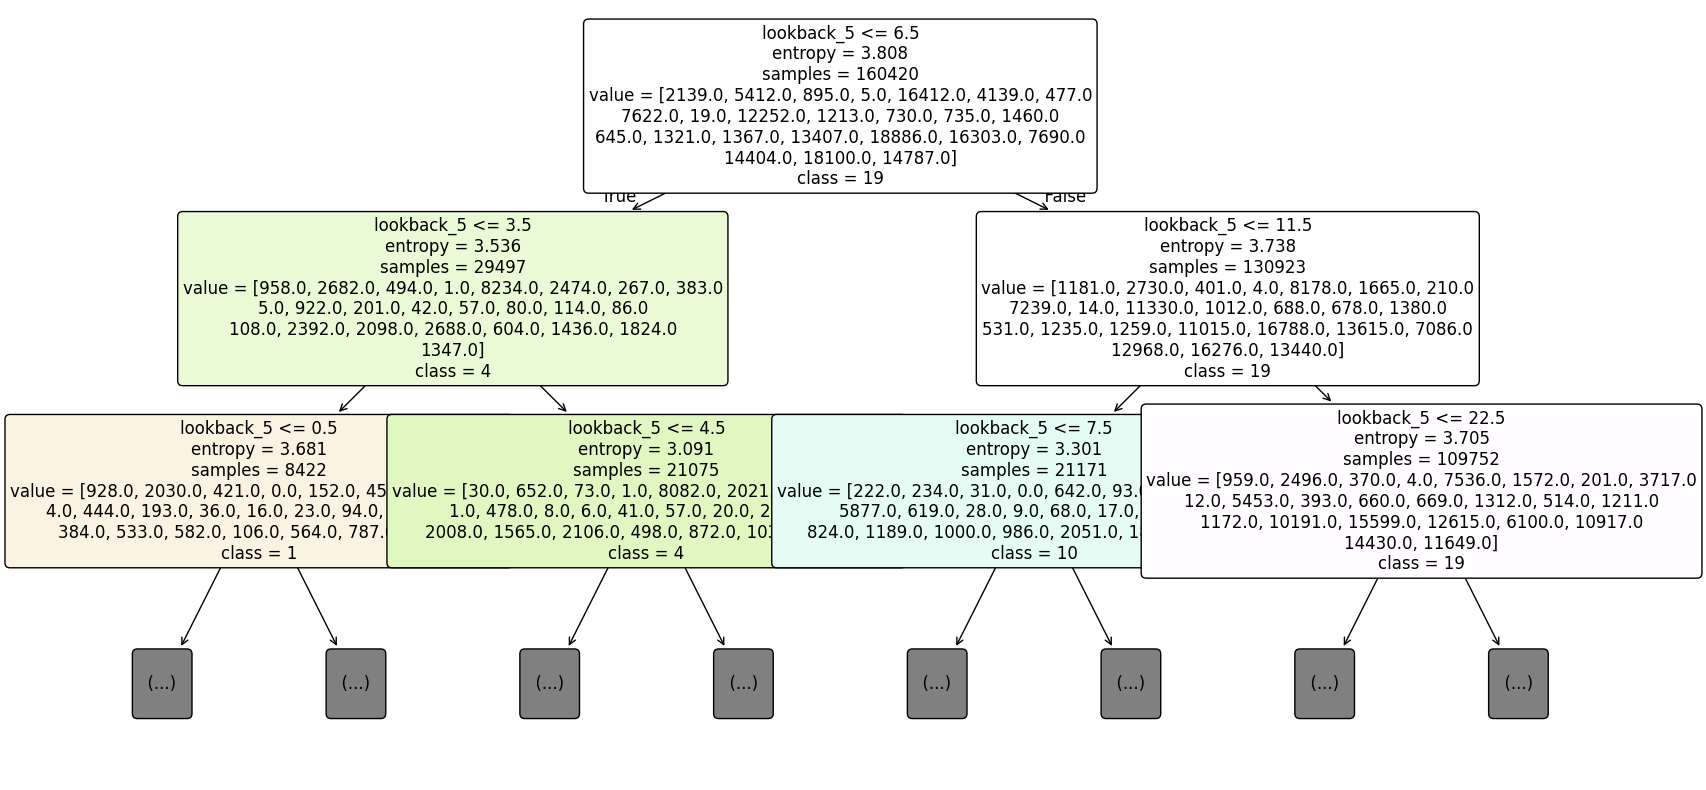

In [16]:
import matplotlib.pyplot as plt
from sklearn import tree

import matplotlib.pyplot as plt
from sklearn import tree
# Every grid search, update the main tree clf_chord. Use it going forward.
best_dt = clf_chord

plt.figure(figsize=(20, 10))

tree.plot_tree(
    best_dt,
    feature_names=Xc_train.columns,
    class_names=best_dt.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=12,
    max_depth=2
)

plt.show()



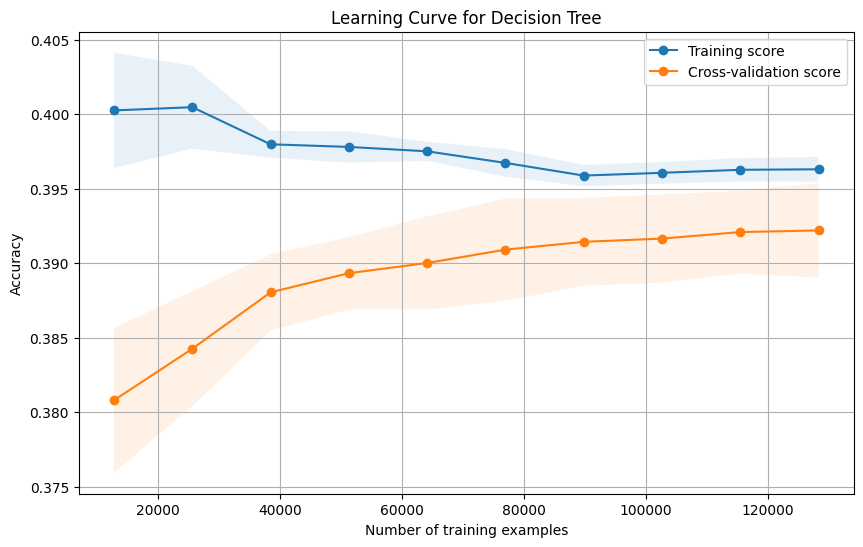

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)

# Get the learning curve of data or binary accuracy of the data as samples increase.
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=Xc_train,
    y=yc_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)


train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', label='Training score')
plt.fill_between(train_sizes_abs,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.1)

plt.plot(train_sizes_abs, val_mean, 'o-', label='Cross-validation score')
plt.fill_between(train_sizes_abs,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.1)

plt.title('Learning Curve for Decision Tree')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()